**This notebook is an exercise in the [Time Series](https://www.kaggle.com/learn/time-series) course.  You can reference the tutorial at [this link](https://www.kaggle.com/ryanholbrook/trend).**

---



# Introduction #

Run this cell to set everything up!

In [1]:
# Setup feedback system
from learntools.core import binder
binder.bind(globals())
from learntools.time_series.ex2 import *

# Setup notebook
from pathlib import Path
from learntools.time_series.style import *  # plot style settings

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.linear_model import LinearRegression

data_dir = Path('../input/ts-course-data/')
comp_dir = Path('../input/store-sales-time-series-forecasting')

retail_sales = pd.read_csv(
    data_dir / "us-retail-sales.csv",
    parse_dates=['Month'],
    index_col='Month',
).to_period('D')
food_sales = retail_sales.loc[:, 'FoodAndBeverage']
auto_sales = retail_sales.loc[:, 'Automobiles']

dtype = {
    'store_nbr': 'category',
    'family': 'category',
    'sales': 'float32',
    'onpromotion': 'uint64',
}
store_sales = pd.read_csv(
    comp_dir / 'train.csv',
    dtype=dtype,
    parse_dates=['date'],
    infer_datetime_format=True,
)
store_sales = store_sales.set_index('date').to_period('D')
store_sales = store_sales.set_index(['store_nbr', 'family'], append=True)
average_sales = store_sales.groupby('date').mean()['sales']

/usr/local/lib/python3.11/dist-packages/learntools/time_series/checking_utils.py:16: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  store_sales = pd.read_csv(


-------------------------------------------------------------------------------

# 1) Determine trend with a moving average plot

The *US Retail Sales* dataset contains monthly sales data for a number of retail industries in the United States. Run the next cell to see a plot of the *Food and Beverage* series.

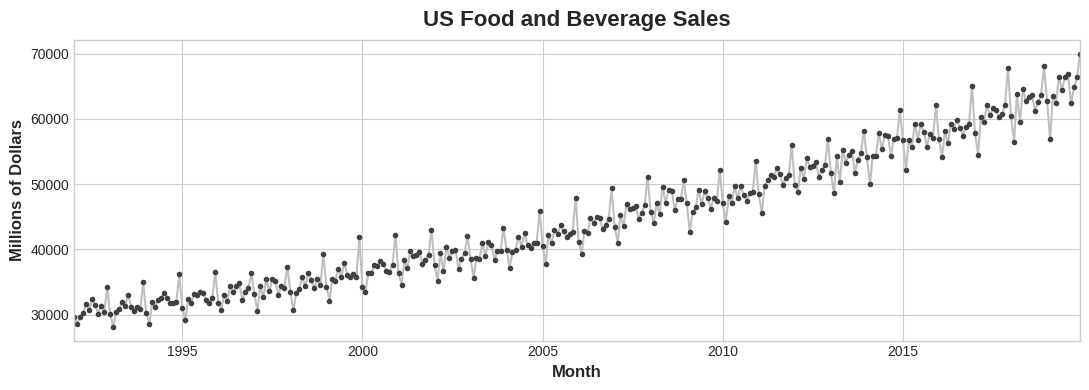

In [2]:
ax = food_sales.plot(**plot_params)
ax.set(title="US Food and Beverage Sales", ylabel="Millions of Dollars");

Now make a moving average plot to estimate the trend for this series.

<IPython.core.display.Javascript object>

<span style="color:#cc3333">Incorrect:</span> Incorrect value for `trend`

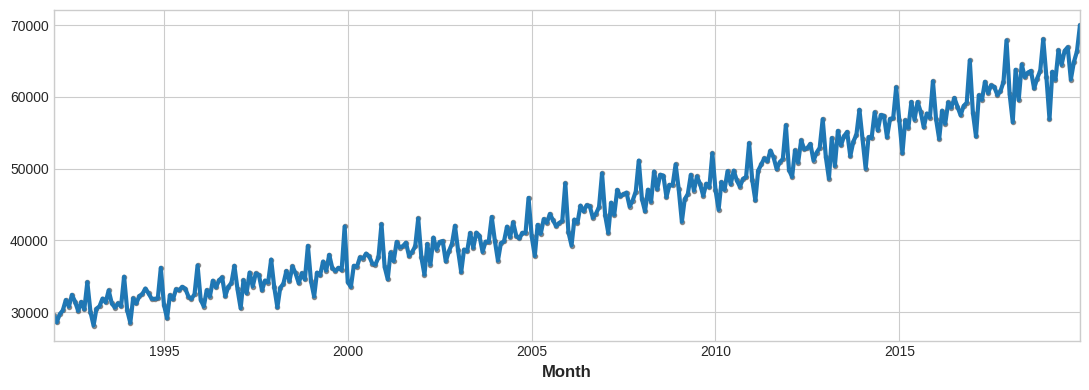

In [3]:
# YOUR CODE HERE: Add methods to `food_sales` to compute a moving
# average with appropriate parameters for trend estimation.
trend = food_sales

# Check your answer
q_1.check()

# Make a plot
ax = food_sales.plot(**plot_params, alpha=0.5)
ax = trend.plot(ax=ax, linewidth=3)

In [4]:
# Uncomment to get a hint or solution
#q_1.hint()
#q_1.solution()

-------------------------------------------------------------------------------

# 2) Identify trend

What order polynomial trend might be appropriate for the *Food and Beverage Sales* series? Can you think of a non-polynomial curve that might work even better?

Once you've thought about it, run this cell for some discussion.

In [5]:
trend = food_sales.rolling(
    window=12,
    center=True,
    min_periods=6,
).mean()

In [6]:
# View the solution (Run this cell to receive credit!)
q_2.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 

The upwards bend in the trend suggests an order 2 (quadratic) polynomial might be appropriate.

If you've worked with economic time series before, you might guess that the growth rate in *Food and Beverage Sales* is best expressed as a percent change. Percent change can often be modeled using an exponential curve. (Don't worry if this isn't familiar!)


-------------------------------------------------------------------------------

We'll continue using the time series of average sales in this lesson. Run this cell to see a moving average plot of `average_sales` estimating the trend.

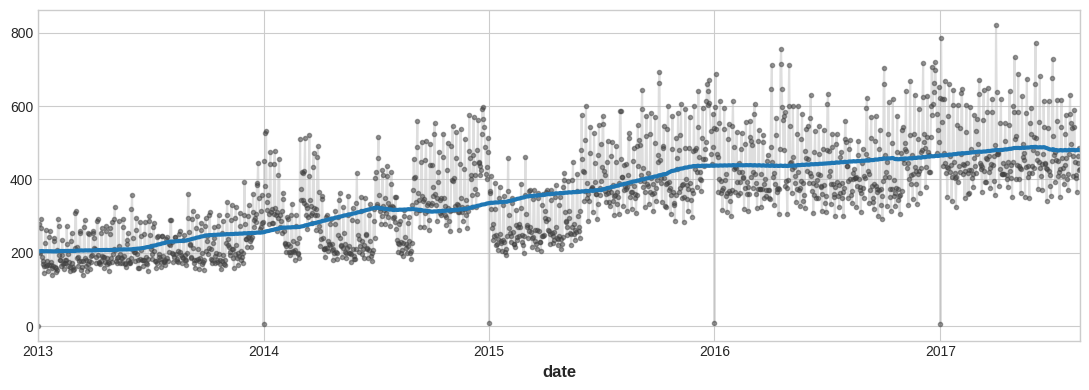

In [7]:
trend = average_sales.rolling(
    window=365,
    center=True,
    min_periods=183,
).mean()

ax = average_sales.plot(**plot_params, alpha=0.5)
ax = trend.plot(ax=ax, linewidth=3)

# 3) Create a Trend Feature

Use `DeterministicProcess` to create a feature set for a cubic trend model. Also create features for a 90-day forecast.

In [8]:
from statsmodels.tsa.deterministic import DeterministicProcess

y = average_sales.copy()  # the target

# YOUR CODE HERE: Instantiate `DeterministicProcess` with arguments
# appropriate for a cubic trend model
dp = DeterministicProcess(index=y.index, order=3)

# YOUR CODE HERE: Create the feature set for the dates given in y.index
X = dp.in_sample()
# YOUR CODE HERE: Create features for a 90-day forecast.
X_fore = dp.out_of_sample(steps=90)


# Check your answer
q_3.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct</span>

In [9]:
# Lines below will give you a hint or solution code
#q_3.hint()
#q_3.solution()

You can see the a plot of the result by running the next cell.

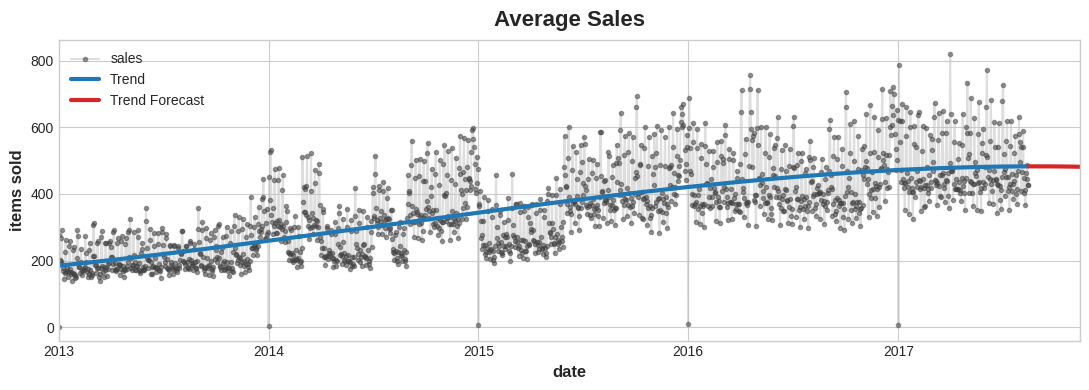

In [10]:
model = LinearRegression()
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)
y_fore = pd.Series(model.predict(X_fore), index=X_fore.index)

ax = y.plot(**plot_params, alpha=0.5, title="Average Sales", ylabel="items sold")
ax = y_pred.plot(ax=ax, linewidth=3, label="Trend", color='C0')
ax = y_fore.plot(ax=ax, linewidth=3, label="Trend Forecast", color='C3')
ax.legend();

--------------------------------------------------------------------------------

One way to fit more complicated trends is to increase the order of the polynomial you use. To get a better fit to the somewhat complicated trend in *Store Sales*, we could try using an order 11 polynomial.

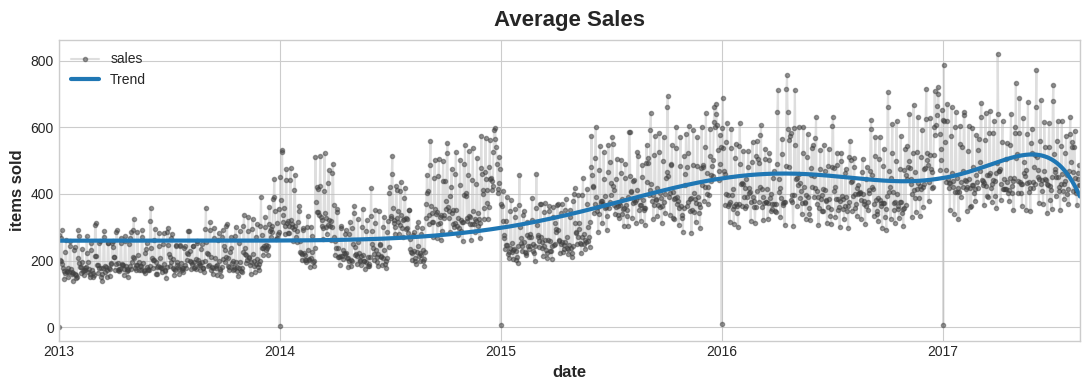

In [11]:
from statsmodels.tsa.deterministic import DeterministicProcess

dp = DeterministicProcess(index=y.index, order=11)
X = dp.in_sample()

model = LinearRegression()
model.fit(X, y)

y_pred = pd.Series(model.predict(X), index=X.index)

ax = y.plot(**plot_params, alpha=0.5, title="Average Sales", ylabel="items sold")
ax = y_pred.plot(ax=ax, linewidth=3, label="Trend", color='C0')
ax.legend();

# 4) Understand risks of forecasting with high-order polynomials

High-order polynomials are generally not well-suited to forecasting, however. Can you guess why?

In [12]:
# View the solution (Run this cell to receive credit!)
q_4.check()

<IPython.core.display.Javascript object>

<span style="color:#33cc33">Correct:</span> 

An order 11 polynomial will include terms like `t ** 11`. Terms like these tend to diverge rapidly outside of the training period making forecasts very unreliable.

In [13]:
# Uncomment the next line for a hint
q_4.hint()

<IPython.core.display.Javascript object>

<span style="color:#3366cc">Hint:</span> What could you say about the rate of change of a term like `t ** 11` over a long period of time?

Run this cell to see the same 90-day forecast using an order 11 polynomial. Does it confirm your intuition?

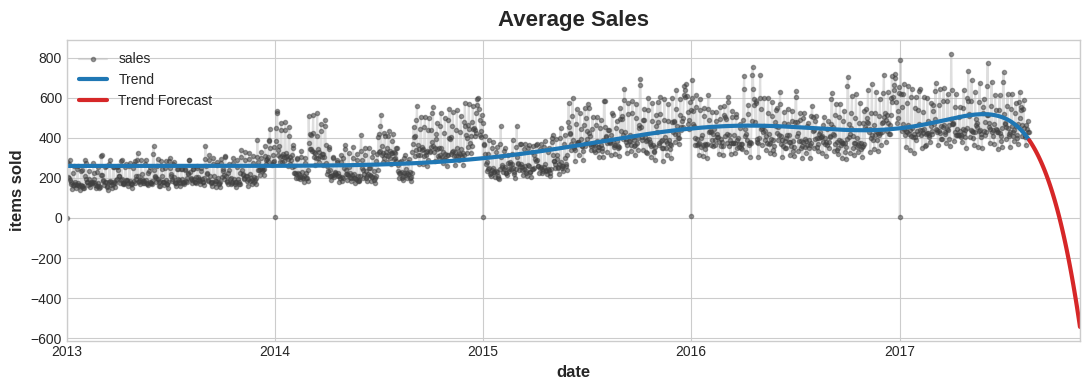

In [14]:
X_fore = dp.out_of_sample(steps=90)
y_fore = pd.Series(model.predict(X_fore), index=X_fore.index)

ax = y.plot(**plot_params, alpha=0.5, title="Average Sales", ylabel="items sold")
ax = y_pred.plot(ax=ax, linewidth=3, label="Trend", color='C0')
ax = y_fore.plot(ax=ax, linewidth=3, label="Trend Forecast", color='C3')
ax.legend();

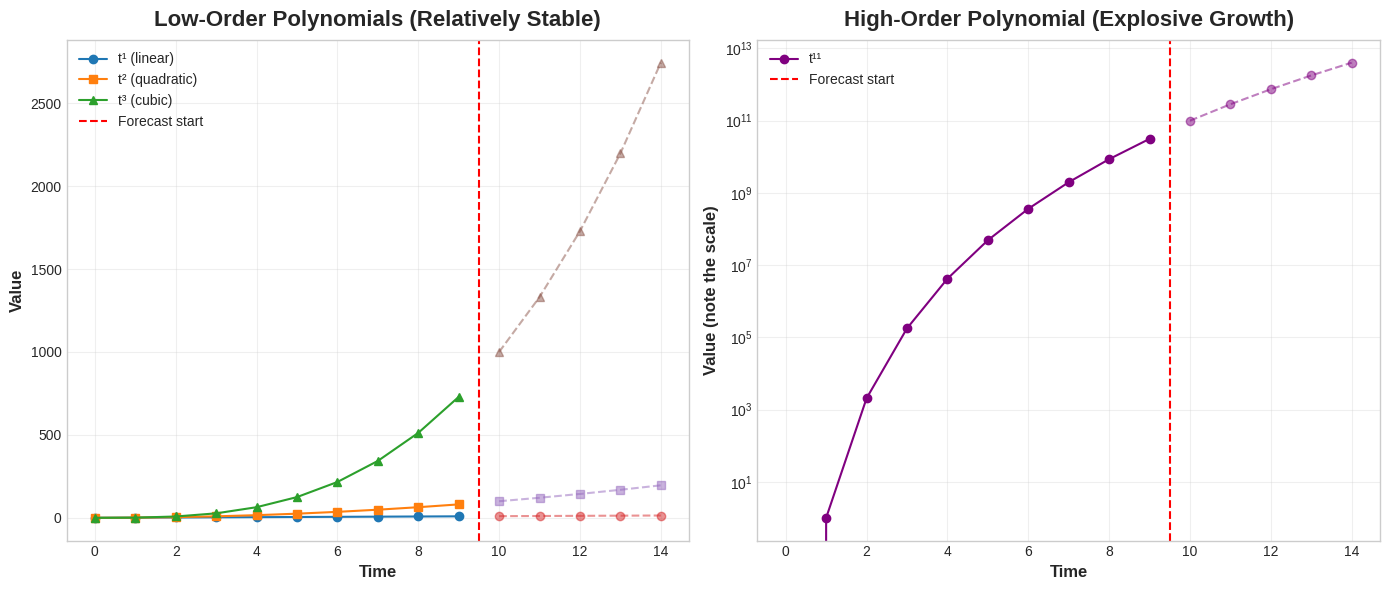

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# Demonstrate the explosive nature of high-order polynomials
t_train = np.arange(0, 10)  # Training period
t_forecast = np.arange(10, 15)  # Forecast period

# Compare different powers
plt.figure(figsize=(14, 6))

# Plot 1: Linear vs Quadratic vs Cubic
plt.subplot(1, 2, 1)
plt.plot(t_train, t_train**1, 'o-', label='t¹ (linear)')
plt.plot(t_train, t_train**2, 's-', label='t² (quadratic)')
plt.plot(t_train, t_train**3, '^-', label='t³ (cubic)')
plt.plot(t_forecast, t_forecast**1, 'o--', alpha=0.5)
plt.plot(t_forecast, t_forecast**2, 's--', alpha=0.5)
plt.plot(t_forecast, t_forecast**3, '^--', alpha=0.5)
plt.axvline(x=9.5, color='red', linestyle='--', label='Forecast start')
plt.title('Low-Order Polynomials (Relatively Stable)')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: High-order polynomial
plt.subplot(1, 2, 2)
plt.plot(t_train, t_train**11, 'o-', label='t¹¹', color='purple')
plt.plot(t_forecast, t_forecast**11, 'o--', color='purple', alpha=0.5)
plt.axvline(x=9.5, color='red', linestyle='--', label='Forecast start')
plt.title('High-Order Polynomial (Explosive Growth)')
plt.xlabel('Time')
plt.ylabel('Value (note the scale)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.yscale('log')  # Log scale to visualize the explosive growth

plt.tight_layout()
plt.show()

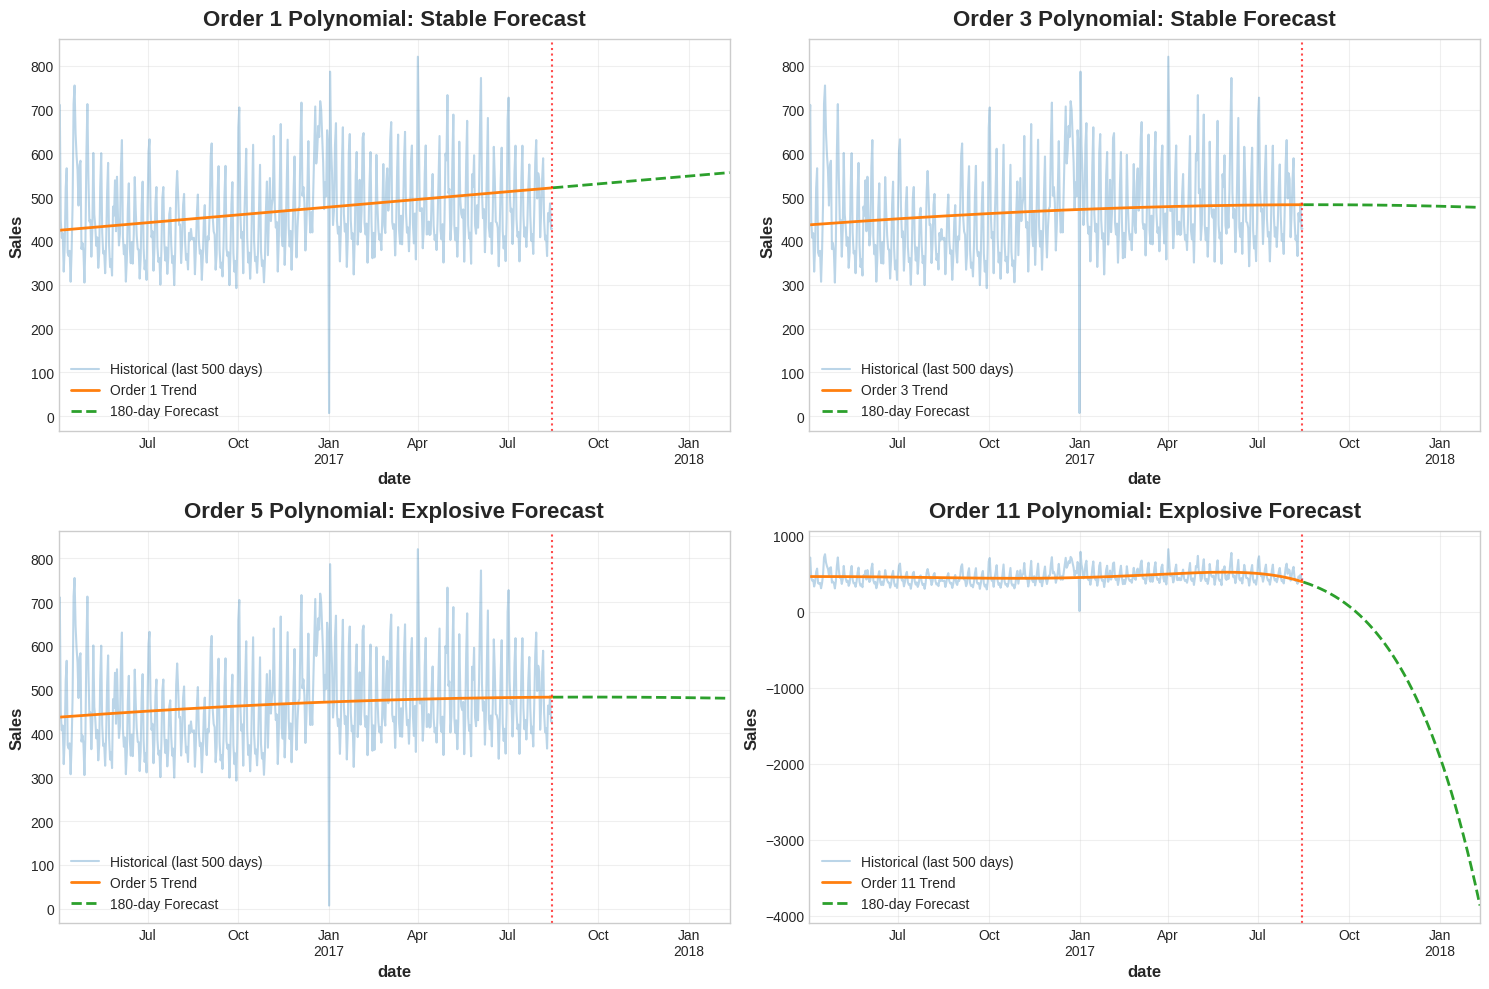

In [16]:
from statsmodels.tsa.deterministic import DeterministicProcess
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt

y = average_sales.copy()

# Compare different polynomial orders
orders = [1, 3, 5, 11]
plt.figure(figsize=(15, 10))

for i, order in enumerate(orders, 1):
    plt.subplot(2, 2, i)
    
    # Fit polynomial trend
    dp = DeterministicProcess(index=y.index, order=order)
    X = dp.in_sample()
    model = LinearRegression()
    model.fit(X, y)
    
    # Historical fit
    y_pred = pd.Series(model.predict(X), index=X.index)
    
    # Forecast 180 days ahead
    X_fore = dp.out_of_sample(steps=180)
    y_fore = pd.Series(model.predict(X_fore), index=X_fore.index)
    
    # Plot
    y[-500:].plot(alpha=0.3, label='Historical (last 500 days)')
    y_pred[-500:].plot(linewidth=2, label=f'Order {order} Trend')
    y_fore.plot(linewidth=2, label=f'180-day Forecast', linestyle='--')
    plt.axvline(x=y.index[-1], color='red', linestyle=':', alpha=0.7)
    plt.title(f'Order {order} Polynomial: {"Stable" if order < 5 else "Explosive"} Forecast')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.ylabel('Sales')

plt.tight_layout()
plt.show()

In [17]:
# Show how coefficients get magnified
orders = [1, 3, 5, 11]
coefficients = []

for order in orders:
    dp = DeterministicProcess(index=y.index, order=order)
    X = dp.in_sample()
    model = LinearRegression()
    model.fit(X, y)
    coefficients.append(model.coef_)

# Create a comparison table
print("Polynomial Order vs Coefficient Magnitude:")
print("-" * 60)
for i, order in enumerate(orders):
    max_coef = np.max(np.abs(coefficients[i]))
    print(f"Order {order:2d}: Max coefficient = {max_coef:.2e}")

Polynomial Order vs Coefficient Magnitude:
------------------------------------------------------------
Order  1: Max coefficient = 1.94e-01
Order  3: Max coefficient = 1.75e-01
Order  5: Max coefficient = 2.05e-01
Order 11: Max coefficient = 3.18e-21


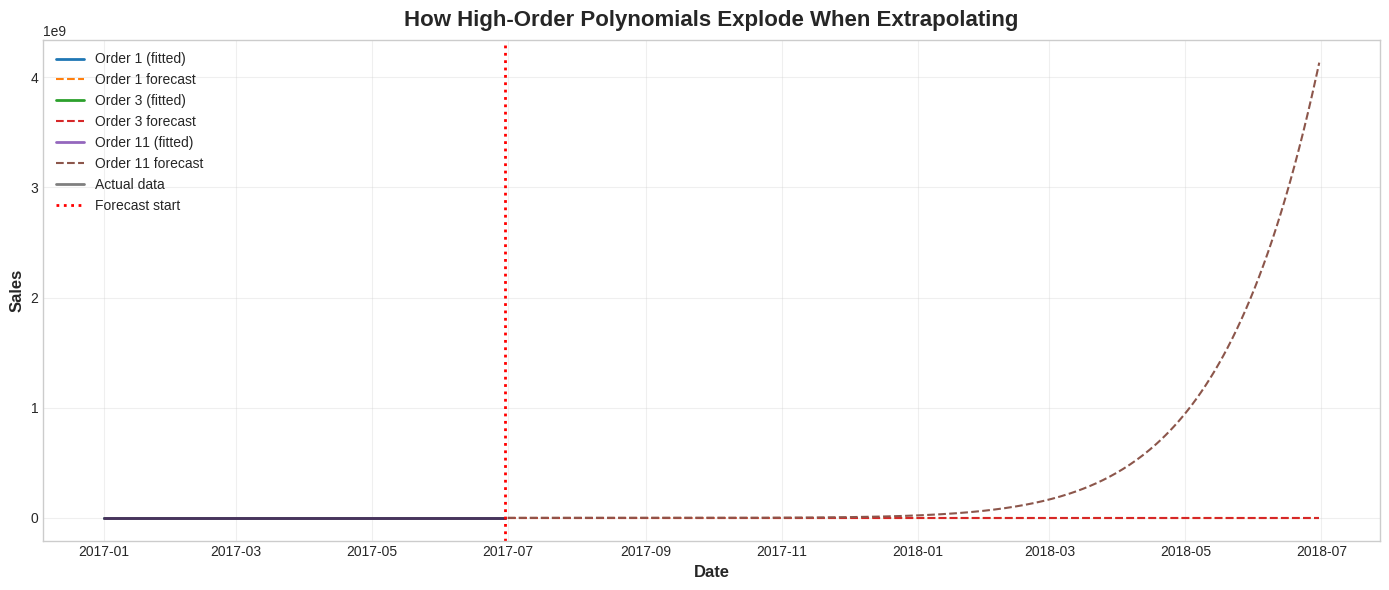

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.deterministic import DeterministicProcess
from sklearn.linear_model import LinearRegression

# Make sure y is defined (using average_sales from earlier)
y = average_sales.copy()

# Demonstrate the extrapolation problem
plt.figure(figsize=(14, 6))

# Take a small subset of data to show the effect
# Convert PeriodIndex to Timestamp for plotting
y_subset = y['2017-01':'2017-06'].copy()
y_subset.index = y_subset.index.to_timestamp()  # Convert to Timestamp for plotting

for order in [1, 3, 11]:
    # Use the original PeriodIndex for modeling
    y_subset_orig = y['2017-01':'2017-06'].copy()
    
    dp = DeterministicProcess(index=y_subset_orig.index, order=order)
    X = dp.in_sample()
    model = LinearRegression()
    model.fit(X, y_subset_orig)
    
    # Fit on the subset
    y_pred = pd.Series(model.predict(X), index=X.index)
    y_pred.index = y_pred.index.to_timestamp()  # Convert for plotting
    
    # Forecast far into the future
    X_fore = dp.out_of_sample(steps=365)  # 1 year forecast
    y_fore = pd.Series(model.predict(X_fore), index=X_fore.index)
    y_fore.index = y_fore.index.to_timestamp()  # Convert for plotting
    
    # Plot
    plt.plot(y_pred.index, y_pred, linewidth=2, label=f'Order {order} (fitted)')
    plt.plot(y_fore.index, y_fore, linestyle='--', 
             label=f'Order {order} forecast')

# Plot actual data (converted to Timestamp)
plt.plot(y_subset.index, y_subset, alpha=0.5, color='black', linewidth=2, label='Actual data')
plt.axvline(x=y_subset.index[-1], color='red', linestyle=':', linewidth=2, label='Forecast start')
plt.title('How High-Order Polynomials Explode When Extrapolating')
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylabel('Sales')
plt.xlabel('Date')
plt.tight_layout()
plt.show()

# Keep Going #

[**Model seasonality**](https://www.kaggle.com/ryanholbrook/seasonality), another common type of time dependence, with indicators and Fourier features.

---




*Have questions or comments? Visit the [course discussion forum](https://www.kaggle.com/learn/time-series/discussion) to chat with other learners.*